In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    roc_auc_score,
    roc_curve,
    classification_report,
    confusion_matrix
)

# Set random seed for reproducibility
np.random.seed(42)
n_samples = 3000

# 1. Synthesize Features
age = np.random.randint(18, 90, n_samples)
prior_visits = np.random.poisson(lam=1.8, size=n_samples)
length_of_stay = np.random.randint(1, 15, n_samples)
systolic_bp = np.random.normal(125, 15, n_samples).round(1)
heart_rate = np.random.normal(78, 10, n_samples).round(1)
diagnosis_code = np.random.choice(
    ['Diabetes', 'Heart Failure', 'COPD', 'Kidney Disease', 'Pneumonia'],
    size=n_samples,
    p=[0.3, 0.25, 0.2, 0.15, 0.1]
)

# 2. Map realistic risk weights to features to create true signal
diag_weights = {'Diabetes': 0.2, 'Heart Failure': 0.8, 'COPD': 0.6, 'Kidney Disease': 0.5, 'Pneumonia': 0.3}
diag_risk = np.array([diag_weights[d] for d in diagnosis_code])

# Logit equation combining risk drivers
logit = (
    -2.5
    + 0.02 * (age - 50)
    + 0.45 * prior_visits
    + 0.15 * length_of_stay
    + 0.01 * (systolic_bp - 120)
    + diag_risk
)

# Convert logit to probabilities using Sigmoid function
prob_readmit = 1 / (1 + np.exp(-logit))
readmitted_30d = np.random.binomial(n=1, p=prob_readmit)

# Construct final DataFrame
data = pd.DataFrame({
    'age': age,
    'prior_visits': prior_visits,
    'length_of_stay': length_of_stay,
    'systolic_bp': systolic_bp,
    'heart_rate': heart_rate,
    'diagnosis_code': diagnosis_code,
    'readmitted_30d': readmitted_30d
})

print("Dataset Preview:")
display(data.head())
print("\nTarget Variable Distribution:")
print(data['readmitted_30d'].value_counts(normalize=True))

Dataset Preview:


,age,prior_visits,length_of_stay,systolic_bp,heart_rate,diagnosis_code,readmitted_30d
0,69,2,14,111.9,80.2,Heart Failure,0
1,32,2,6,117.6,82.0,Pneumonia,0
2,89,0,14,129.9,76.4,Kidney Disease,1
3,78,4,12,143.4,70.8,Heart Failure,1
4,38,2,4,142.6,78.0,Heart Failure,1



Target Variable Distribution:
readmitted_30d
0    0.512333
1    0.487667
Name: proportion, dtype: float64


In [ ]:
# Features and Target split
X = data.drop(columns=['readmitted_30d'])
y = data['readmitted_30d']

# Identify column types
numeric_features = ['age', 'prior_visits', 'length_of_stay', 'systolic_bp', 'heart_rate']
categorical_features = ['diagnosis_code']

# Construct ColumnTransformer for scaling and encoding
preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), numeric_features),
        ('cat', OneHotEncoder(drop='first', handle_unknown='ignore'), categorical_features)
    ]
)

# Train-Test Split (80/20) with stratification
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=42, stratify=y
)

# Transform Data
X_train_proc = preprocessor.fit_transform(X_train)
X_test_proc = preprocessor.transform(X_test)

# Retrieve transformed feature names
encoded_cat_names = list(preprocessor.named_transformers_['cat'].get_feature_names_out(categorical_features))
feature_names = numeric_features + encoded_cat_names

print(f"Processed Training Shape: {X_train_proc.shape}")
print(f"Processed Testing Shape: {X_test_proc.shape}")

Processed Training Shape: (2400, 9)
Processed Testing Shape: (600, 9)


In [ ]:
# Instantiate Logistic Regression with L2 Regularization
# C=0.5 applies moderate penalty (smaller C = stronger regularization)
model = LogisticRegression(
    penalty='l2',
    C=0.5,
    solver='lbfgs',
    max_iter=1000,
    random_state=42
)

# Fit model
model.fit(X_train_proc, y_train)

# Predict class probabilities and default labels
y_probs = model.predict_proba(X_test_proc)[:, 1]
y_pred_default = model.predict(X_test_proc)

print("Logistic Regression Model Trained Successfully.")

Logistic Regression Model Trained Successfully.


ROC-AUC Score: 0.7578



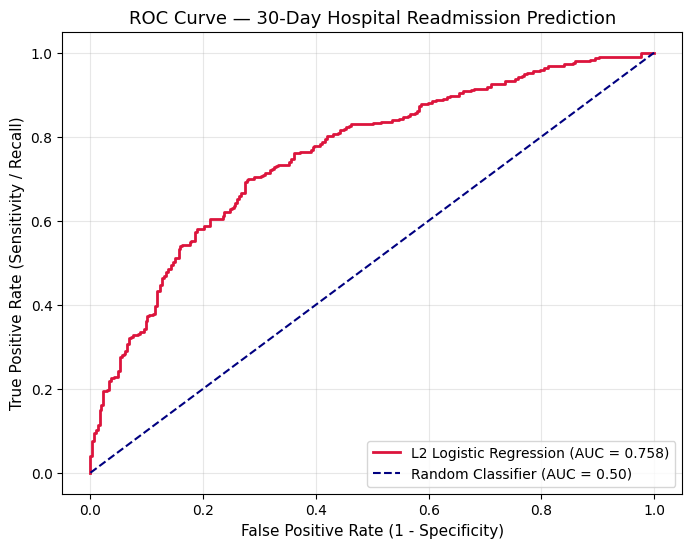

Default Threshold (0.5) Classification Metrics:
              precision    recall  f1-score   support

           0       0.70      0.73      0.71       307
           1       0.70      0.67      0.68       293

    accuracy                           0.70       600
   macro avg       0.70      0.70      0.70       600
weighted avg       0.70      0.70      0.70       600



In [ ]:
# Calculate ROC-AUC Score
auc_score = roc_auc_score(y_test, y_probs)
print(f"ROC-AUC Score: {auc_score:.4f}\n")

# Compute ROC Curve
fpr, tpr, thresholds = roc_curve(y_test, y_probs)

# Plot ROC Curve
plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, color='crimson', lw=2, label=f'L2 Logistic Regression (AUC = {auc_score:.3f})')
plt.plot([0, 1], [0, 1], color='navy', linestyle='--', label='Random Classifier (AUC = 0.50)')
plt.xlabel('False Positive Rate (1 - Specificity)', fontsize=11)
plt.ylabel('True Positive Rate (Sensitivity / Recall)', fontsize=11)
plt.title('ROC Curve — 30-Day Hospital Readmission Prediction', fontsize=13)
plt.legend(loc='lower right')
plt.grid(True, alpha=0.3)
plt.show()

# Classification Report at default 0.5 threshold
print("Default Threshold (0.5) Classification Metrics:")
print(classification_report(y_test, y_pred_default))

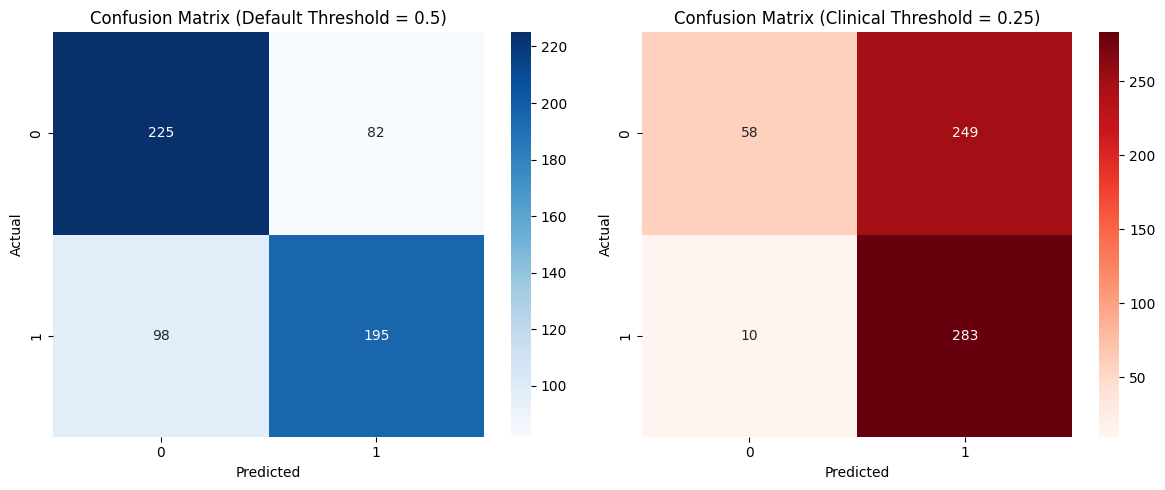

Default (0.50)  -> False Negatives: 98 | False Positives: 82
Clinical (0.25) -> False Negatives: 10 | False Positives: 249


In [ ]:
# Evaluate threshold shift for clinical decision making
# Lowering threshold prioritizes minimizing False Negatives (unmonitored readmissions)

clinical_threshold = 0.25  # Decision threshold tuned for medical risk
y_pred_clinical = (y_probs >= clinical_threshold).astype(int)

cm_default = confusion_matrix(y_test, y_pred_default)
cm_clinical = confusion_matrix(y_test, y_pred_clinical)

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

sns.heatmap(cm_default, annot=True, fmt='d', cmap='Blues', ax=axes[0])
axes[0].set_title("Confusion Matrix (Default Threshold = 0.5)")
axes[0].set_xlabel("Predicted")
axes[0].set_ylabel("Actual")

sns.heatmap(cm_clinical, annot=True, fmt='d', cmap='Reds', ax=axes[1])
axes[1].set_title(f"Confusion Matrix (Clinical Threshold = {clinical_threshold})")
axes[1].set_xlabel("Predicted")
axes[1].set_ylabel("Actual")

plt.tight_layout()
plt.show()

fn_default = cm_default[1, 0]
fn_clinical = cm_clinical[1, 0]
fp_default = cm_default[0, 1]
fp_clinical = cm_clinical[0, 1]

print(f"Default (0.50)  -> False Negatives: {fn_default} | False Positives: {fp_default}")
print(f"Clinical ({clinical_threshold}) -> False Negatives: {fn_clinical} | False Positives: {fp_clinical}")